In [4]:
! pip install pandas
! pip install numpy
! pip install scikit-learn
! pip install matplotlib
! pip install seaborn

  Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl (11.5 MB)
Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl (12.6 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
  Using cached scikit_learn-1.6.1-cp313-cp313-win_amd64.whl.metadata (15 kB)
  Using cached scipy-1.15.2-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.6.1-cp313-cp313-win_amd64.whl (11.1 MB)
Using cached joblib-1.4.2-py3-none-any.whl (301 kB)
Using cached scipy-1.15.2-cp313-cp313-win_amd64.whl (41.0 MB)
Using cached threadpoolctl-3.

In [5]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("Top Indian Places to Visit.csv", low_memory=False)
df.columns

Index(['Unnamed: 0', 'Zone', 'State', 'City', 'Name', 'Type',
       'Establishment Year', 'time needed to visit in hrs',
       'Google review rating', 'Entrance Fee in INR',
       'Airport with 50km Radius', 'Weekly Off', 'Significance',
       'DSLR Allowed', 'Number of google review in lakhs',
       'Best Time to visit'],
      dtype='object')

In [7]:
places = df[['Name', 'Type', 'Google review rating', 'Number of google review in lakhs','time needed to visit in hrs', 'Entrance Fee in INR', 'Significance']].copy()

places = places.dropna(subset=['Type', 'Google review rating', 'Number of google review in lakhs', 'time needed to visit in hrs', 'Entrance Fee in INR', 'Significance'])

In [8]:
places = pd.get_dummies(places, columns=['Type', 'Significance'], drop_first=True)

In [9]:
scaler = MinMaxScaler()
numerical_features = ['Google review rating', 'Number of google review in lakhs', 'time needed to visit in hrs', 'Entrance Fee in INR']
places[numerical_features] = scaler.fit_transform(places[numerical_features])

In [10]:
features = places.drop(columns=['Name']).values

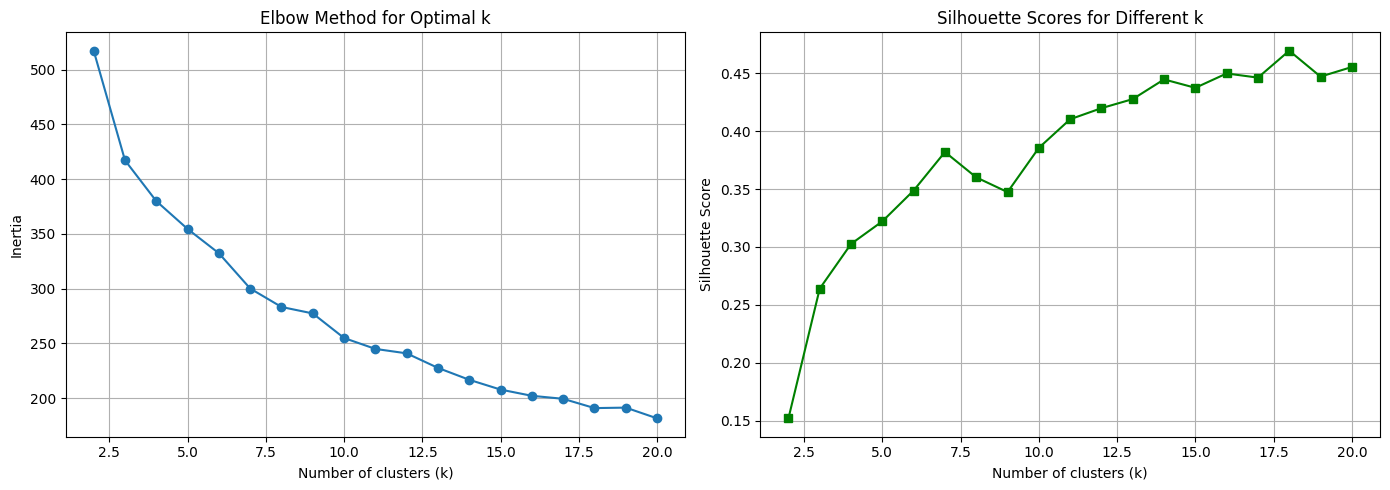

In [11]:
inertia_values = []
silhouette_scores = []
k_values = range(2, 21)

for k in k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42)
    kmeans_model.fit(features)
    inertia_values.append(kmeans_model.inertia_)
    silhouette_scores.append(silhouette_score(features, kmeans_model.labels_))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(k_values, inertia_values, marker='o')
axs[0].set_title('Elbow Method for Optimal k')
axs[0].set_xlabel('Number of clusters (k)')
axs[0].set_ylabel('Inertia')
axs[0].grid(True)

axs[1].plot(k_values, silhouette_scores, marker='s', color='green')
axs[1].set_title('Silhouette Scores for Different k')
axs[1].set_xlabel('Number of clusters (k)')
axs[1].set_ylabel('Silhouette Score')
axs[1].grid(True)

plt.tight_layout()
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_9872\2386462264.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis')


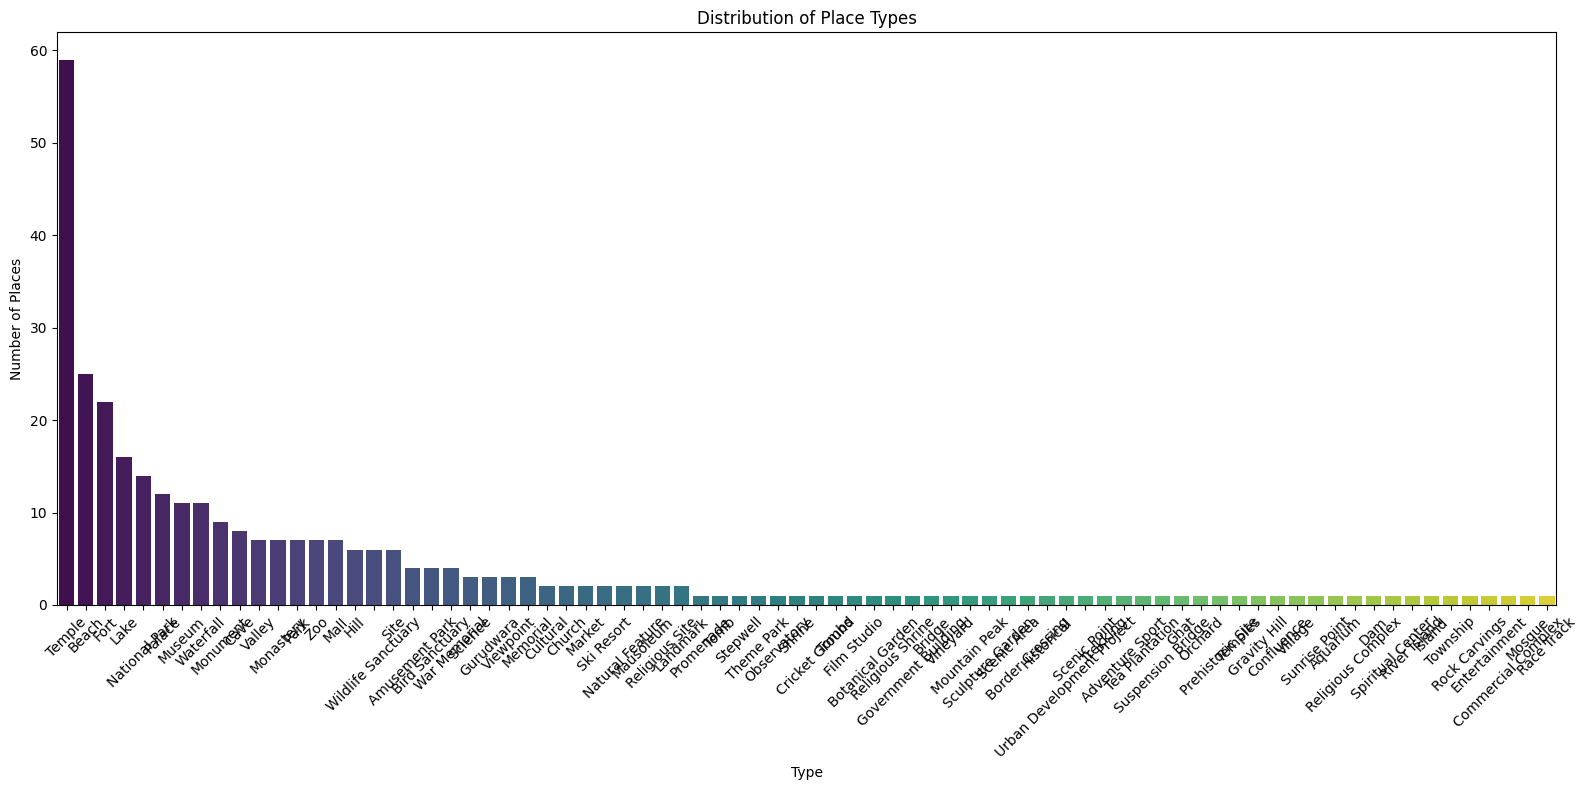

In [12]:
type_counts = df['Type'].value_counts()

plt.figure(figsize=(16, 8))
sns.barplot(x=type_counts.index, y=type_counts.values, palette='viridis')
plt.title('Distribution of Place Types')
plt.xticks(rotation=45)
plt.ylabel('Number of Places')
plt.xlabel('Type')
plt.tight_layout()
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_9872\2244132295.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=places['Cluster'], palette='coolwarm')


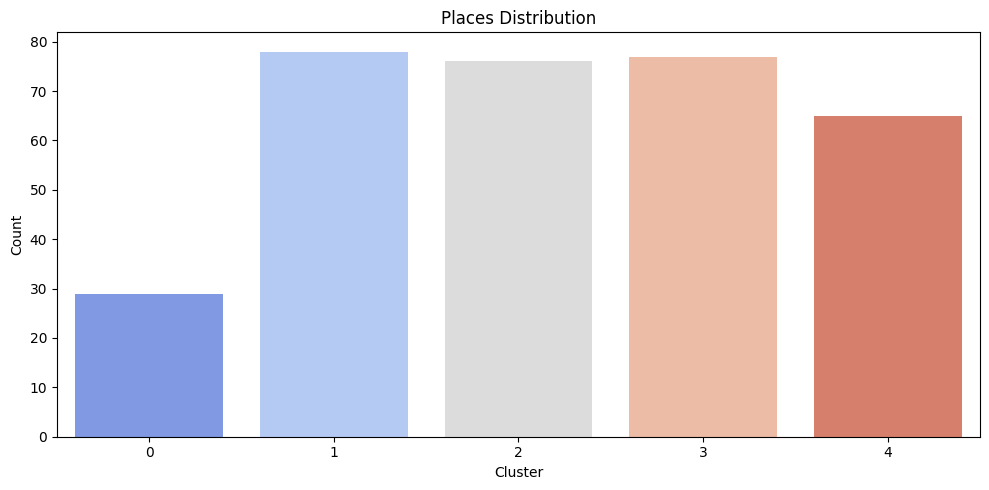

In [13]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
places['Cluster'] = kmeans.fit_predict(features)
plt.figure(figsize=(10, 5))
sns.countplot(x=places['Cluster'], palette='coolwarm')
plt.title('Places Distribution')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [16]:
def recommend_places(place_name, n=5):
    """
    Recommend similar places based on clustering.

    Parameters:
        place_name (str): Name of the place to base recommendations on.
        n (int): Number of similar places to return.

    Returns:
        pd.DataFrame: Top N recommended places in the same cluster.
    """
    
    target = places[places['Name'].str.lower() == place_name.lower()]
    
    if target.empty:
        return f"Place named '{place_name}' not found in the dataset."
    
    cluster_id = target['Cluster'].values[0]
    
    similar_places = places[(places['Cluster'] == cluster_id) & 
                            (places['Name'].str.lower() != place_name.lower())]
    
    return similar_places[['Name', 'Google review rating', 'Entrance Fee in INR']].sort_values(
        by=['Google review rating', 'Entrance Fee in INR'], ascending=[False, True]).head(n)

In [27]:
print("Recommended places similar to 'Belur Math':")
print(recommend_places("Belur Math", n=5))

Recommended places similar to 'Belur Math':
                          Name  Google review rating  Entrance Fee in INR
20        Siddhivinayak Temple              0.971429                  0.0
71              Somnath Temple              0.971429                  0.0
130         Mahalakshmi Temple              0.971429                  0.0
140  Mahakaleshwar Jyotirlinga              0.971429                  0.0
154              Key Monastery              0.971429                  0.0
